# Задача 1. Разведочный анализ HR-метрик и прогноз нагрузки на рекрутинг до 2027 года

В работе рассматривается датасет `df_ITs.csv`, содержащий исторические показатели IT-департаментов за 2020–2024 годы. Цель анализа — описать динамику HR-нагрузки и построить прогноз общего количества обработанных резюме до 2027 года.

Целевая переменная для прогнозирования — `yearly_cv_processed`. Она показывает, сколько резюме было обработано за год, поэтому далее используется как основной показатель нагрузки на рекрутинг.

## 1. Импорт библиотек и загрузка данных

Файл с данными должен находиться в одной папке с ноутбуком и называться `Для задачи 1_ df_ITs.csv`. В коде сразу фиксируются ожидаемые столбцы, чтобы решение было воспроизводимым и не зависело от автоматического поиска структуры таблицы.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

DATA_PATH = Path('data/df_ITs.csv')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

EXPECTED_COLUMNS = [
    'department_id', 'year', 'tech_stack', 'current_staff_count',
    'yearly_cv_processed', 'share_seniors', 'active_projects_count',
    'inbound_applications', 'avg_dev_salary', 'devs_hired',
    'devs_fired', 'turnover_rate', 'tech_brand_rating',
    'total_salary_budget'
]

raw_df = pd.read_csv(DATA_PATH)
raw_df = raw_df[EXPECTED_COLUMNS]

print(f'Размер исходной таблицы: {raw_df.shape[0]} строк, {raw_df.shape[1]} столбцов')
display(raw_df.head())

Размер исходной таблицы: 2526 строк, 14 столбцов


,department_id,year,tech_stack,current_staff_count,yearly_cv_processed,share_seniors,active_projects_count,inbound_applications,avg_dev_salary,devs_hired,devs_fired,turnover_rate,tech_brand_rating,total_salary_budget
0,1000000.0,2020.0,Стадион,392.0,5847.0,4.591837,231.0,1969.0,110277.784723,77.0,52.0,0.329082,0.6,51877245.0
1,1000000.0,2021.0,Стадион,445.0,6688.0,6.292135,258.0,2415.0,123862.871896,119.0,47.0,0.373034,0.6,66162037.0
2,1000000.0,2022.0,Стадион,514.0,7503.0,7.198444,291.0,2544.0,122932.673766,143.0,60.0,0.394942,0.6,75827728.0
3,1000000.0,2023.0,Стадион,587.0,8272.0,8.858603,327.0,3426.0,123735.907223,103.0,63.0,0.282794,0.8,87165251.0
4,1000000.0,2024.0,Стадион,632.0,9267.0,11.550633,362.0,3318.0,141861.433957,91.0,96.0,0.295886,0.2,107592482.0


## 2. Проверка качества данных и подготовка таблицы

В таблице есть одна полностью пустая строка и небольшое количество пропусков в числовых признаках. Пустая строка удаляется. Пропуски заполняются последовательно: сначала интерполяцией внутри одного департамента по годам, затем медианой по связке `tech_stack + year`, затем медианой по году и общей медианой столбца. Такой порядок выбран потому, что он сохраняет временную структуру данных и не смешивает разные технологические направления без необходимости.

In [2]:
missing_before = pd.DataFrame({
    'dtype': raw_df.dtypes.astype(str),
    'missing_count': raw_df.isna().sum(),
    'missing_share_%': (raw_df.isna().mean() * 100).round(2),
    'unique_count': raw_df.nunique(dropna=True)
})

print('Количество полностью пустых строк:', int(raw_df.isna().all(axis=1).sum()))
print('Количество явных дубликатов:', int(raw_df.duplicated().sum()))
display(missing_before)

Количество полностью пустых строк: 1
Количество явных дубликатов: 0


,dtype,missing_count,missing_share_%,unique_count
department_id,float64,1,0.04,505
year,float64,1,0.04,5
tech_stack,object,1,0.04,15
current_staff_count,float64,19,0.75,336
yearly_cv_processed,float64,8,0.32,1876
share_seniors,float64,22,0.87,1564
active_projects_count,float64,8,0.32,220
inbound_applications,float64,37,1.46,1173
avg_dev_salary,float64,19,0.75,2507
devs_hired,float64,26,1.03,100


In [3]:
df = raw_df.dropna(how='all').copy()

df['department_id'] = df['department_id'].astype(int)
df['year'] = df['year'].astype(int)

numeric_columns = [
    'current_staff_count', 'yearly_cv_processed', 'share_seniors',
    'active_projects_count', 'inbound_applications', 'avg_dev_salary',
    'devs_hired', 'devs_fired', 'turnover_rate', 'tech_brand_rating',
    'total_salary_budget'
]

df_clean = df.sort_values(['department_id', 'year']).copy()

for column in numeric_columns:
    df_clean[column] = df_clean.groupby('department_id')[column].transform(
        lambda values: values.interpolate(limit_direction='both')
    )
    df_clean[column] = df_clean[column].fillna(
        df_clean.groupby(['tech_stack', 'year'])[column].transform('median')
    )
    df_clean[column] = df_clean[column].fillna(
        df_clean.groupby('year')[column].transform('median')
    )
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

print(f'После очистки: {df_clean.shape[0]} строк, {df_clean.shape[1]} столбцов')
print('Осталось пропусков:', int(df_clean.isna().sum().sum()))
print('Период наблюдений:', int(df_clean['year'].min()), '-', int(df_clean['year'].max()))
print('Количество департаментов:', df_clean['department_id'].nunique())
print('Количество направлений tech_stack:', df_clean['tech_stack'].nunique())

После очистки: 2525 строк, 14 столбцов
Осталось пропусков: 0
Период наблюдений: 2020 - 2024
Количество департаментов: 505
Количество направлений tech_stack: 15


## 3. Описательная статистика

После подготовки данных рассчитаны основные статистики по числовым признакам. Они позволяют оценить масштаб показателей: размер департаментов, количество активных проектов, входящие отклики, найм, увольнения, текучесть и зарплатный бюджет.

In [4]:
descriptive_stats = df_clean.describe().T.round(2)
display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max
department_id,2525.0,1000252.00,145.81,1000000.00,1000126.00,1000252.00,1000378.00,1.000504e+06
year,2525.0,2022.00,1.41,2020.00,2021.00,2022.00,2023.00,2.024000e+03
current_staff_count,2525.0,138.38,74.30,10.00,86.00,126.00,176.00,6.370000e+02
yearly_cv_processed,2525.0,2130.05,1276.49,41.00,1234.00,1953.00,2758.00,1.075400e+04
share_seniors,2525.0,24.31,7.37,3.33,19.81,24.29,28.67,6.897000e+01
active_projects_count,2525.0,81.51,45.20,2.00,49.00,76.00,104.00,3.940000e+02
inbound_applications,2525.0,698.14,701.42,0.00,365.00,574.00,888.00,1.722600e+04
avg_dev_salary,2525.0,126474.57,16824.82,46800.17,115407.32,124923.85,135472.29,2.056626e+05
devs_hired,2525.0,16.31,15.30,1.00,8.00,13.00,20.00,1.530000e+02
devs_fired,2525.0,16.80,11.45,1.00,10.00,15.00,21.00,1.290000e+02


## 4. Годовая динамика нагрузки на рекрутинг

Для прогноза используется агрегирование по годам: суммарное количество обработанных резюме, входящих откликов, штат, активные проекты, найм, увольнения и средние значения текучести и рейтинга бренда.

In [5]:
annual = df_clean.groupby('year').agg(
    total_cv_processed=('yearly_cv_processed', 'sum'),
    total_inbound_applications=('inbound_applications', 'sum'),
    total_staff=('current_staff_count', 'sum'),
    total_projects=('active_projects_count', 'sum'),
    total_hired=('devs_hired', 'sum'),
    total_fired=('devs_fired', 'sum'),
    mean_turnover=('turnover_rate', 'mean'),
    mean_brand_rating=('tech_brand_rating', 'mean')
).reset_index()

annual['cv_yoy_%'] = annual['total_cv_processed'].pct_change() * 100
annual['inbound_yoy_%'] = annual['total_inbound_applications'].pct_change() * 100
annual['cv_per_staff'] = annual['total_cv_processed'] / annual['total_staff']

display(annual.round(2))

,year,total_cv_processed,total_inbound_applications,total_staff,total_projects,total_hired,total_fired,mean_turnover,mean_brand_rating,cv_yoy_%,inbound_yoy_%,cv_per_staff
0,2020,998769.0,306498.0,66580.00,38942.0,6675.00,6826.5,0.21,0.26,NaN,NaN,15.00
1,2021,1051656.0,322541.0,68119.50,40547.0,8753.67,7587.5,0.25,0.32,5.30,5.23,15.44
2,2022,1089353.0,355413.0,71340.17,41595.0,8825.33,8761.0,0.26,0.33,3.58,10.19,15.27
3,2023,1112104.0,399220.0,71951.33,42415.0,8994.00,8894.0,0.26,0.36,2.09,12.33,15.46
4,2024,1126493.0,379136.0,71411.00,42313.0,7935.00,10362.5,0.27,0.35,1.29,-5.03,15.77


Суммарная нагрузка на рекрутинг растет каждый год: с 998 769 обработанных резюме в 2020 году до 1 126 493 в 2024 году. Общий прирост за период составил около 12,8%. При этом темп роста постепенно снижается: с 5,3% в 2021 году до 1,29% в 2024 году. Это важно для прогноза: продолжать высокий ранний темп роста без поправки на замедление было бы слишком оптимистично.

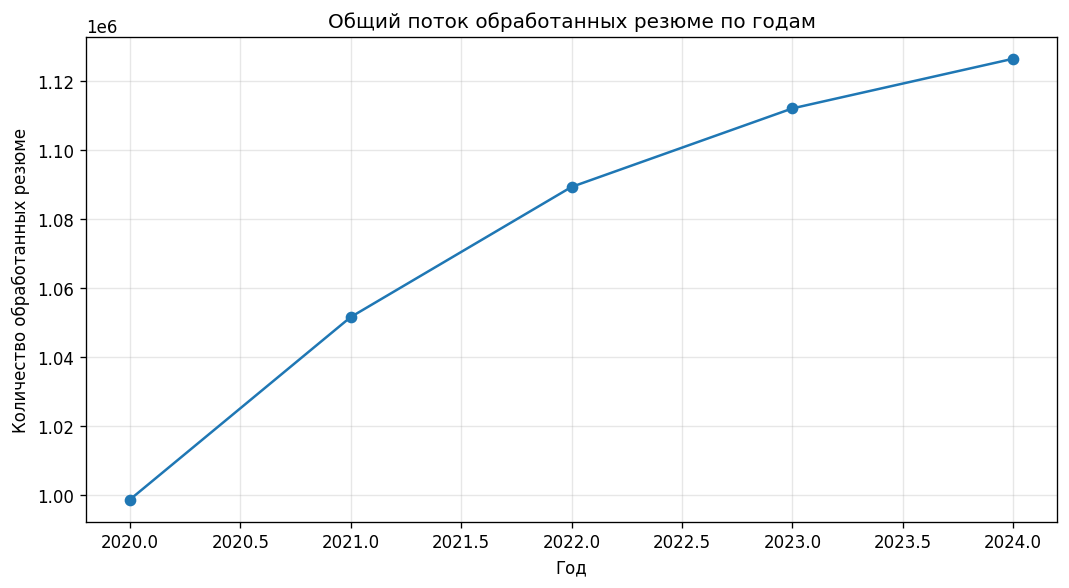

In [6]:
plt.figure(figsize=(9, 5))
plt.plot(annual['year'], annual['total_cv_processed'], marker='o')
plt.title('Общий поток обработанных резюме по годам')
plt.xlabel('Год')
plt.ylabel('Количество обработанных резюме')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

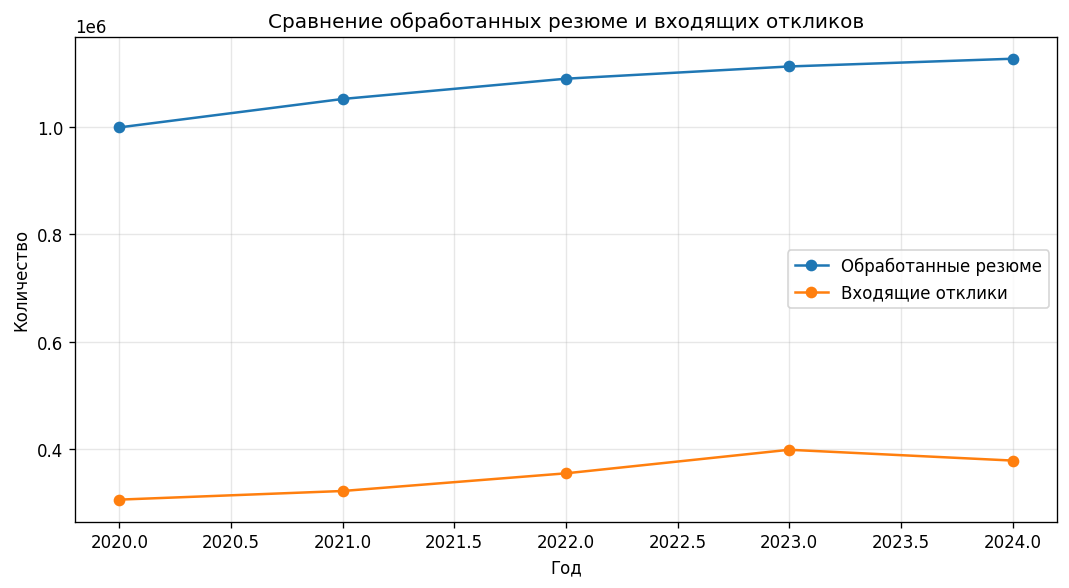

In [7]:
plt.figure(figsize=(9, 5))
plt.plot(annual['year'], annual['total_cv_processed'], marker='o', label='Обработанные резюме')
plt.plot(annual['year'], annual['total_inbound_applications'], marker='o', label='Входящие отклики')
plt.title('Сравнение обработанных резюме и входящих откликов')
plt.xlabel('Год')
plt.ylabel('Количество')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Входящие отклики растут до 2023 года, но в 2024 году снижаются примерно на 5%. При этом количество обработанных резюме продолжает расти. Это означает, что нагрузка на рекрутинг поддерживается не только самостоятельными откликами, но и другими каналами поиска кандидатов.

## 5. Распределение нагрузки по направлениям `tech_stack`

Далее анализируется 2024 год как последний фактический период. Это позволяет понять, какие направления формируют наибольшую часть текущей нагрузки.

In [8]:
tech_2024 = (
    df_clean[df_clean['year'] == 2024]
    .groupby('tech_stack')
    .agg(
        cv_processed=('yearly_cv_processed', 'sum'),
        departments=('department_id', 'nunique'),
        staff=('current_staff_count', 'sum')
    )
    .sort_values('cv_processed', ascending=False)
)
tech_2024['share_%'] = tech_2024['cv_processed'] / tech_2024['cv_processed'].sum() * 100

display(tech_2024.round(2))

,cv_processed,departments,staff,share_%
tech_stack,,,,
Вокзал,98972.0,40,6208.0,8.79
Аэропорт,98037.0,45,5974.0,8.70
Стадион,91069.0,37,5785.0,8.08
Жилой_район,87326.0,43,5789.0,7.75
Торговый_центр,87264.0,32,5455.0,7.75
Туристический_центр,82149.0,37,5071.0,7.29
Промзона,82051.0,38,5125.0,7.28
Парк,74427.0,34,4877.0,6.61
ЖД_станция,68127.0,29,4321.0,6.05


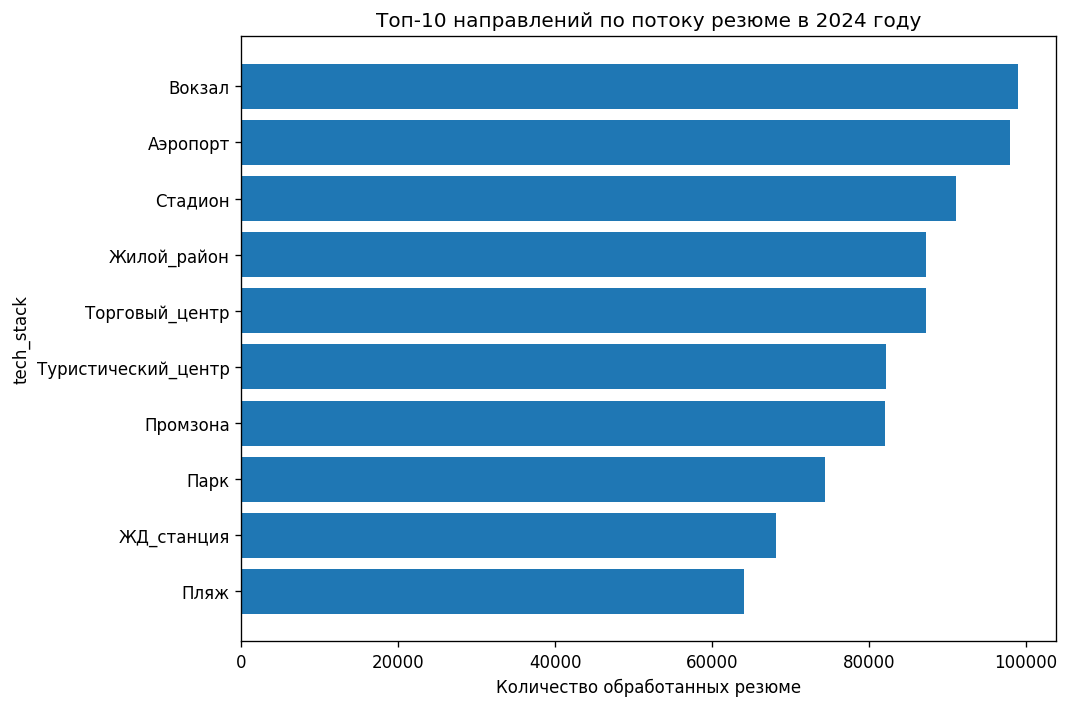

In [9]:
top_tech = tech_2024.head(10).sort_values('cv_processed')

plt.figure(figsize=(9, 6))
plt.barh(top_tech.index, top_tech['cv_processed'])
plt.title('Топ-10 направлений по потоку резюме в 2024 году')
plt.xlabel('Количество обработанных резюме')
plt.ylabel('tech_stack')
plt.tight_layout()
plt.show()

Наибольшая нагрузка в 2024 году приходится на направления `Вокзал`, `Аэропорт`, `Стадион`, `Жилой_район` и `Торговый_центр`. Каждое из этих направлений дает примерно 7,7–8,8% общего потока резюме. Распределение не выглядит полностью монопольным: нагрузка заметно распределена между несколькими крупными направлениями.

## 6. Связи между признаками

Для интерпретации данных рассчитаны корреляции числовых признаков с целевой переменной `yearly_cv_processed`. Это не доказывает причинность, но показывает, какие факторы статистически сильнее связаны с объемом рекрутинговой нагрузки.

In [10]:
corr_with_target = (
    df_clean.select_dtypes(include=[np.number])
    .corr(numeric_only=True)['yearly_cv_processed']
    .sort_values(ascending=False)
    .to_frame('corr_with_yearly_cv_processed')
)

display(corr_with_target.round(3))

,corr_with_yearly_cv_processed
yearly_cv_processed,1.000
active_projects_count,0.979
current_staff_count,0.944
total_salary_budget,0.940
inbound_applications,0.627
tech_brand_rating,0.560
devs_fired,0.548
devs_hired,0.528
avg_dev_salary,0.310
year,0.069


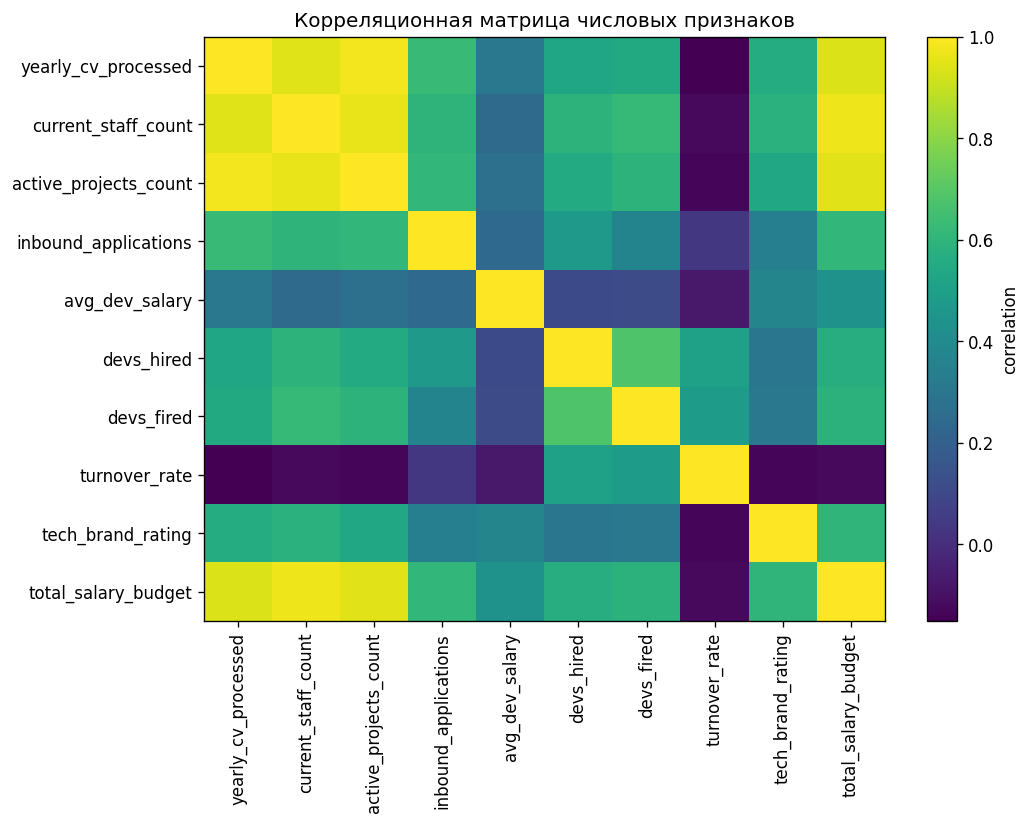

In [11]:
corr_columns = [
    'yearly_cv_processed', 'current_staff_count', 'active_projects_count',
    'inbound_applications', 'avg_dev_salary', 'devs_hired', 'devs_fired',
    'turnover_rate', 'tech_brand_rating', 'total_salary_budget'
]

corr_matrix = df_clean[corr_columns].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix, aspect='auto')
plt.xticks(range(len(corr_columns)), corr_columns, rotation=90)
plt.yticks(range(len(corr_columns)), corr_columns)
plt.colorbar(label='correlation')
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()

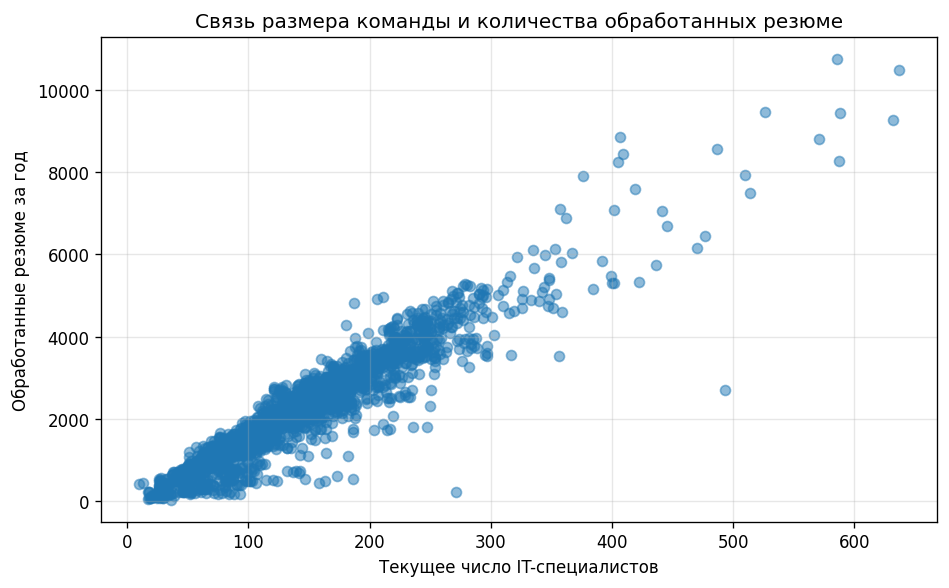

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean['current_staff_count'], df_clean['yearly_cv_processed'], alpha=0.5)
plt.title('Связь размера команды и количества обработанных резюме')
plt.xlabel('Текущее число IT-специалистов')
plt.ylabel('Обработанные резюме за год')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Самая сильная связь с целевой переменной наблюдается у количества активных проектов, размера команды и общего зарплатного бюджета. Это логично: более крупные департаменты с большим числом проектов обычно требуют большего объема найма и, соответственно, создают большую нагрузку на рекрутинг. Также заметна положительная связь с количеством входящих откликов, наймом и увольнениями.

## 7. Прогнозирование общего потока кандидатов до 2027 года

В данных есть только пять годовых периодов, поэтому сложные временные модели здесь не используются: они были бы нестабильны и плохо интерпретируемы. Вместо этого строятся несколько простых сценариев:

- консервативный сценарий: значение 2024 года сохраняется без изменений;
- CAGR-сценарий: продолжение среднегодового темпа роста 2020–2024 годов;
- линейный тренд по суммарному годовому потоку;
- bottom-up линейный тренд: отдельный линейный прогноз по каждому департаменту с последующим суммированием;
- сценарий медианного роста департаментов: продолжение типичного темпа роста на уровне департаментов с ограничением экстремальных скачков.

Итоговый базовый прогноз рассчитывается как среднее по ростовым сценариям. Консервативный сценарий используется отдельно как нижняя граница.

In [13]:
def get_total_by_year(data: pd.DataFrame) -> pd.Series:
    return data.groupby('year')['yearly_cv_processed'].sum().sort_index()


def forecast_naive(totals: pd.Series, years: list[int]) -> dict[int, float]:
    last_value = totals.iloc[-1]
    return {year: float(last_value) for year in years}


def forecast_cagr(totals: pd.Series, years: list[int]) -> dict[int, float]:
    first_year = int(totals.index.min())
    last_year = int(totals.index.max())
    first_value = float(totals.loc[first_year])
    last_value = float(totals.loc[last_year])
    cagr = (last_value / first_value) ** (1 / (last_year - first_year)) - 1
    return {year: float(last_value * (1 + cagr) ** (year - last_year)) for year in years}


def forecast_linear_total(totals: pd.Series, years: list[int]) -> dict[int, float]:
    X = totals.index.to_numpy().reshape(-1, 1)
    y = totals.to_numpy()
    model = LinearRegression().fit(X, y)
    return {year: float(model.predict(np.array([[year]]))[0]) for year in years}


def forecast_bottom_up_linear(data: pd.DataFrame, years: list[int]) -> dict[int, float]:
    result = {year: 0.0 for year in years}

    for _, group in data.groupby('department_id'):
        department_series = group.groupby('year')['yearly_cv_processed'].sum().sort_index()
        X = department_series.index.to_numpy().reshape(-1, 1)
        y = department_series.to_numpy()
        model = LinearRegression().fit(X, y)

        for year in years:
            prediction = float(model.predict(np.array([[year]]))[0])
            result[year] += max(0.0, prediction)

    return result


def forecast_department_median_growth(
    data: pd.DataFrame,
    years: list[int],
    lower_growth: float = -0.10,
    upper_growth: float = 0.15
) -> dict[int, float]:
    last_year = int(data['year'].max())
    last_total = float(data[data['year'] == last_year]['yearly_cv_processed'].sum())

    department_growth_rates = []
    for _, group in data.groupby('department_id'):
        department_series = group.groupby('year')['yearly_cv_processed'].sum().sort_index()
        growth = department_series.pct_change().replace([np.inf, -np.inf], np.nan).dropna()
        if len(growth) > 0:
            department_growth_rates.append(float(growth.median()))

    median_growth = float(np.median(department_growth_rates))
    median_growth = float(np.clip(median_growth, lower_growth, upper_growth))

    return {
        year: float(last_total * (1 + median_growth) ** (year - last_year))
        for year in years
    }

### Проверка прогноза на 2024 год

Чтобы оценить устойчивость сценариев, выполнена проверка на последнем известном годе: модели обучаются на 2020–2023 годах и прогнозируют 2024 год. Затем прогноз сравнивается с фактическим значением 2024 года.

In [14]:
backtest_train = df_clean[df_clean['year'] <= 2023].copy()
actual_2024 = float(df_clean[df_clean['year'] == 2024]['yearly_cv_processed'].sum())
train_totals = get_total_by_year(backtest_train)

backtest_predictions = {
    'conservative_naive': forecast_naive(train_totals, [2024])[2024],
    'cagr': forecast_cagr(train_totals, [2024])[2024],
    'linear_total': forecast_linear_total(train_totals, [2024])[2024],
    'bottom_up_linear': forecast_bottom_up_linear(backtest_train, [2024])[2024],
    'department_median_growth': forecast_department_median_growth(backtest_train, [2024])[2024]
}

backtest = pd.DataFrame({
    'model': list(backtest_predictions.keys()),
    'forecast_2024': list(backtest_predictions.values())
})
backtest['actual_2024'] = actual_2024
backtest['abs_error'] = (backtest['forecast_2024'] - backtest['actual_2024']).abs()
backtest['error_%'] = (backtest['forecast_2024'] - backtest['actual_2024']) / backtest['actual_2024'] * 100

display(backtest.round(2))

,model,forecast_2024,actual_2024,abs_error,error_%
0,conservative_naive,1112104.00,1126493.0,14389.00,-1.28
1,cagr,1152671.40,1126493.0,26178.40,2.32
2,linear_total,1157396.00,1126493.0,30903.00,2.74
3,bottom_up_linear,1157396.00,1126493.0,30903.00,2.74
4,department_median_growth,1134371.77,1126493.0,7878.77,0.70


На проверке 2024 года все сценарии дают умеренную ошибку. Наиболее близким оказался сценарий медианного роста департаментов, но остальные ростовые сценарии также дают ошибку всего в несколько процентов. Поэтому для итогового прогноза используется усреднение нескольких ростовых сценариев, а не один выбранный вариант.

In [15]:
forecast_years = [2025, 2026, 2027]
full_totals = get_total_by_year(df_clean)

scenario_forecasts = pd.DataFrame({
    'conservative_naive': forecast_naive(full_totals, forecast_years),
    'cagr': forecast_cagr(full_totals, forecast_years),
    'linear_total': forecast_linear_total(full_totals, forecast_years),
    'bottom_up_linear': forecast_bottom_up_linear(df_clean, forecast_years),
    'department_median_growth': forecast_department_median_growth(df_clean, forecast_years)
}).T

growth_scenarios = ['cagr', 'linear_total', 'bottom_up_linear', 'department_median_growth']
base_forecast = scenario_forecasts.loc[growth_scenarios].mean(axis=0)

forecast_result = pd.DataFrame({
    'year': forecast_years,
    'base_forecast_total_cv_processed': [base_forecast.loc[year] for year in forecast_years],
    'conservative_scenario': [scenario_forecasts.loc['conservative_naive', year] for year in forecast_years],
    'upper_scenario': [scenario_forecasts.drop(index='conservative_naive')[year].max() for year in forecast_years]
})
forecast_result['growth_vs_2024_%'] = (
    forecast_result['base_forecast_total_cv_processed'] / actual_2024 - 1
) * 100

print('Сценарные прогнозы:')
display(scenario_forecasts.round(2))

print('Итоговый прогноз:')
display(forecast_result.round(2))

Сценарные прогнозы:
Итоговый прогноз:


,2025,2026,2027
conservative_naive,1126493.00,1126493.00,1126493.00
cagr,1160898.79,1196355.41,1232894.97
linear_total,1170443.80,1202033.40,1233623.00
bottom_up_linear,1170465.30,1202351.40,1234507.80
department_median_growth,1143316.32,1160390.88,1177720.44


,year,base_forecast_total_cv_processed,conservative_scenario,upper_scenario,growth_vs_2024_%
0,2025,1161281.05,1126493.0,1170465.3,3.09
1,2026,1190282.77,1126493.0,1202351.4,5.66
2,2027,1219686.55,1126493.0,1234507.8,8.27


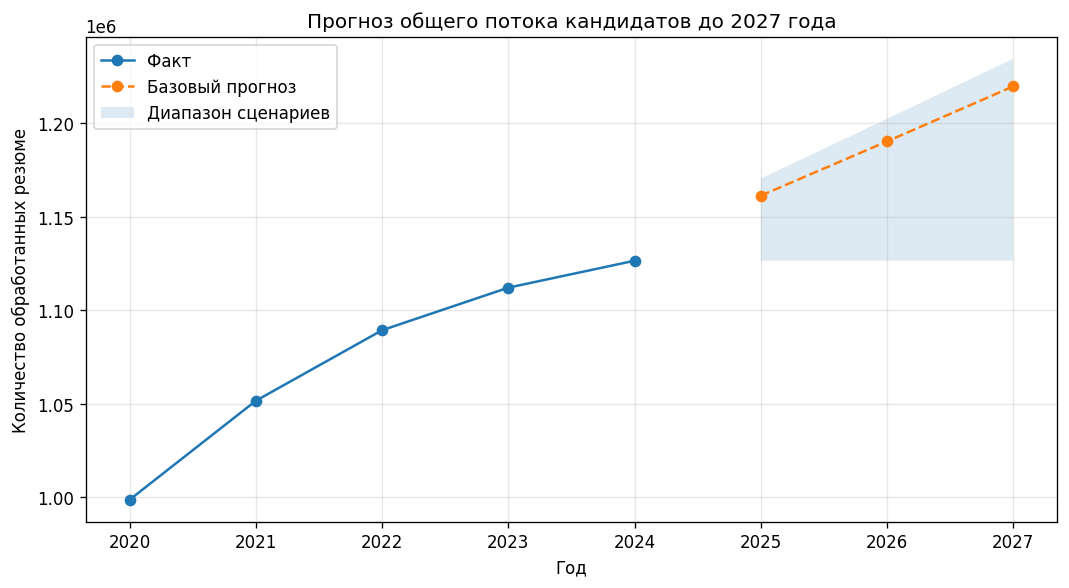

In [16]:
plt.figure(figsize=(9, 5))
plt.plot(annual['year'], annual['total_cv_processed'], marker='o', label='Факт')
plt.plot(
    forecast_result['year'],
    forecast_result['base_forecast_total_cv_processed'],
    marker='o',
    linestyle='--',
    label='Базовый прогноз'
)
plt.fill_between(
    forecast_result['year'],
    forecast_result['conservative_scenario'],
    forecast_result['upper_scenario'],
    alpha=0.15,
    label='Диапазон сценариев'
)
plt.title('Прогноз общего потока кандидатов до 2027 года')
plt.xlabel('Год')
plt.ylabel('Количество обработанных резюме')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
forecast_result.to_csv(OUTPUT_DIR / 'forecast_2025_2027_task1.csv', index=False, encoding='utf-8-sig')
print(f'Файл с прогнозом сохранен: {OUTPUT_DIR / 'forecast_2025_2027_task1.csv'}')

Файл с прогнозом сохранен: forecast_2025_2027_task1.csv


## 8. Итоговые выводы

После удаления одной пустой строки в датасете осталось 2525 наблюдений: 505 департаментов за период с 2020 по 2024 год. Данные покрывают 15 направлений `tech_stack`, что позволяет анализировать как общую динамику нагрузки на рекрутинг, так и распределение нагрузки между направлениями.

Суммарное количество обработанных резюме выросло с 998 769 в 2020 году до 1 126 493 в 2024 году. Общий прирост составил около 12,8%. При этом годовой темп роста снижался: 5,3% в 2021 году, 3,58% в 2022 году, 2,09% в 2023 году и 1,29% в 2024 году. Следовательно, при прогнозировании важно учитывать не только сам факт роста, но и его замедление.

Наибольшая нагрузка в 2024 году приходится на направления `Вокзал`, `Аэропорт`, `Стадион`, `Жилой_район` и `Торговый_центр`. При этом ни одно направление не доминирует полностью: крупнейшее направление формирует менее 9% годового потока резюме.

Корреляционный анализ показал, что количество обработанных резюме сильнее всего связано с числом активных проектов, размером команды и общим зарплатным бюджетом. Это означает, что рост нагрузки на рекрутинг в основном связан с масштабом департамента и интенсивностью проектной деятельности.

По базовому прогнозу общий поток обработанных резюме составит примерно 1 161 281 в 2025 году, 1 190 283 в 2026 году и 1 219 687 в 2027 году. По сравнению с 2024 годом ожидаемый рост нагрузки к 2027 году составляет около 8,27%.

Практический вывод: если процесс рекрутинга останется без изменений, нагрузка на HR-команду продолжит расти. Поэтому к 2027 году потребуется либо увеличение пропускной способности рекрутинга, либо автоматизация части этапов отбора, либо перераспределение ресурсов в направлениях с наибольшим потоком кандидатов.